In [33]:
from uszipcode import SearchEngine
import pandas as pd
import seaborn as sns
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
from scipy.stats import mstats, pearsonr
import sqlite3
from fuzzywuzzy import fuzz
import altair as alt

warnings.filterwarnings('ignore')
# Optional in Jupyter Notebook: requires an up-to-date vega nbextension.
alt.renderers.enable('notebook')

RendererRegistry.enable('notebook')

In [34]:
raw_data_order_df = pd.read_excel('carpets_data.xlsx', sheet_name='Raw Data-Order and Sample')
order_data_df = pd.read_excel('carpets_data.xlsx', sheet_name='Data Order ONLY')
sample_data_df = pd.read_excel('carpets_data.xlsx', sheet_name='Data on Sample ONLY')
recommendation_data_df = pd.read_excel('carpets_data.xlsx', sheet_name='Data for Recommendation')
clustering_data_df = pd.read_excel('carpets_data.xlsx', sheet_name='Data for Clustering')
association_rules_data_df = pd.read_excel('carpets_data.xlsx', sheet_name='Data - Association Rules A-11 ')

In [35]:
raw_data_order_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18955 entries, 0 to 18954
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderType        18955 non-null  object        
 1   OrderCategory    18955 non-null  object        
 2   CustomerCode     18955 non-null  object        
 3   CountryName      18955 non-null  object        
 4   CustomerOrderNo  18946 non-null  object        
 5   Custorderdate    18955 non-null  datetime64[ns]
 6   UnitName         18955 non-null  object        
 7   QtyRequired      18955 non-null  int64         
 8   TotalArea        18955 non-null  float64       
 9   Amount           18955 non-null  float64       
 10  ITEM_NAME        18955 non-null  object        
 11  QualityName      18955 non-null  object        
 12  DesignName       18955 non-null  object        
 13  ColorName        18955 non-null  object        
 14  ShapeName        18955 non-null  objec

In [36]:
raw_data_order_df.columns

Index(['OrderType', 'OrderCategory', 'CustomerCode', 'CountryName',
       'CustomerOrderNo', 'Custorderdate', 'UnitName', 'QtyRequired',
       'TotalArea', 'Amount', 'ITEM_NAME', 'QualityName', 'DesignName',
       'ColorName', 'ShapeName', 'AreaFt'],
      dtype='object')

In [37]:
raw_data_order_df['OrderType'].value_counts()

Area Wise    14206
Pc Wise       4749
Name: OrderType, dtype: int64

### Top Countries by Revenue/Orders amount

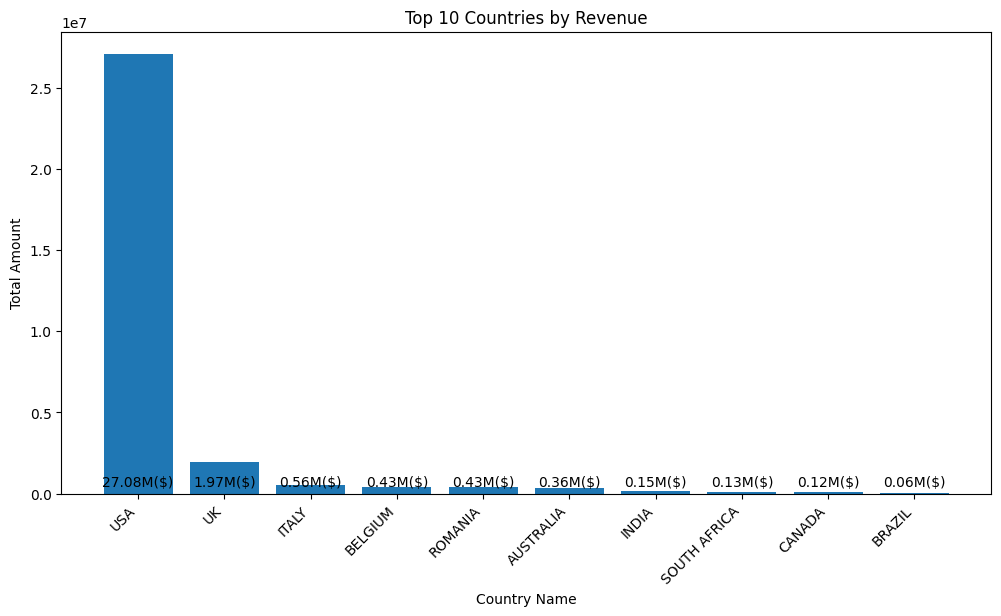

In [53]:
country_amount = raw_data_order_df.groupby('CountryName')['Amount'].sum()

# Sort in descending order and select top 10
top_10_countries = country_amount.sort_values(ascending=False).head(10)

# Plotting the bar chart with data labels
plt.figure(figsize=(12, 6))
bars = plt.bar(top_10_countries.index, top_10_countries.values)
plt.xlabel('Country Name')
plt.ylabel('Total Amount')
plt.title('Top 10 Countries by Revenue')
plt.xticks(rotation=45, ha="right")  # Rotate x-axis labels for better readability

# Add data labels in millions of dollars (M$) rounded to two decimals
for bar in bars:
    height = bar.get_height() / 1e6  # Convert to millions
    label = f'{height:.2f}M($)'  # Format with M($) and two decimals
    plt.annotate(label, 
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),  # 3 points vertical offset
                 textcoords="offset points",
                 ha='center', va='bottom')


plt.show()

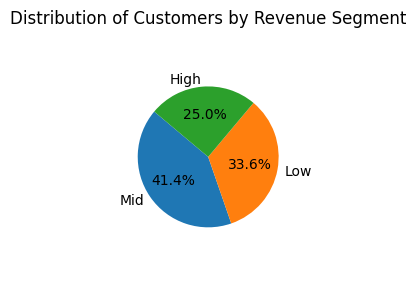

In [62]:


# Calculate 25th, 50th (median), and 75th percentiles of `Amount`
low_percentile = raw_data_order_df['Amount'].quantile(0.25)
mid_percentile = raw_data_order_df['Amount'].quantile(0.50)
high_percentile = raw_data_order_df['Amount'].quantile(0.75)

# Create labels for the segments
labels = ['Low', 'Mid', 'High']

# Assign each customer to a segment based on their `Amount`
raw_data_order_df['RevenueSegment'] = pd.cut(raw_data_order_df['Amount'], bins=[-float('inf'), low_percentile, high_percentile, float('inf')], labels=labels)

# Calculate the number of customers in each segment (if not already done)
segment_counts = raw_data_order_df['RevenueSegment'].value_counts()

# Plotting with Matplotlib
plt.figure(figsize=(2, 3.25))  # Adjust size as needed
plt.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Customers by Revenue Segment')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

plt.savefig('customer_revenue_segment_pie_chart.png')  # Save as PNG
plt.show()

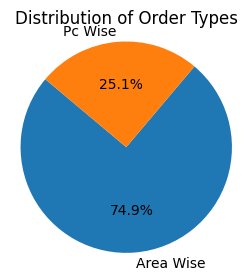

In [66]:

# Calculate the count of occurrences for each unique value in `OrderType` and `OrderCategory`
order_type_counts = raw_data_order_df['OrderType'].value_counts()
order_category_counts = raw_data_order_df['OrderCategory'].value_counts()

# Convert the Series to a DataFrame for plotting
order_type_df = order_type_counts.reset_index()

# Plotting
plt.figure(figsize=(3, 3))
plt.pie(order_type_df['OrderType'], labels=order_type_df['index'], autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Order Types')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

plt.savefig('order_type_pie_chart.png')  # Save as PNG (or other format)
plt.show()

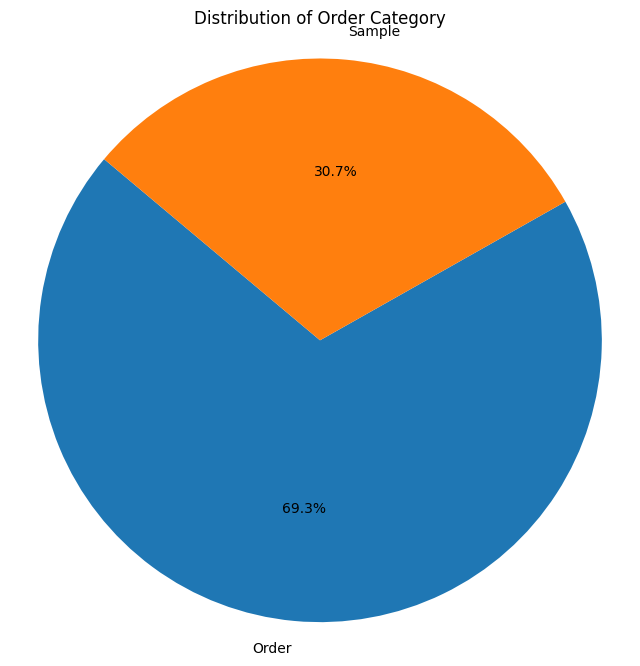

In [69]:

# Calculate the count of occurrences for each unique value in `OrderType` and `OrderCategory`
order_category_counts = raw_data_order_df['OrderCategory'].value_counts()

# Convert the Series to a DataFrame for plotting
order_category_df = order_category_counts.reset_index()

# Plotting
plt.figure(figsize=(8, 8))
plt.pie(order_category_df['OrderCategory'], labels=order_category_df['index'], autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Order Category')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

plt.savefig('order_Category_pie_chart.png')  # Save as PNG (or other format)
plt.show()

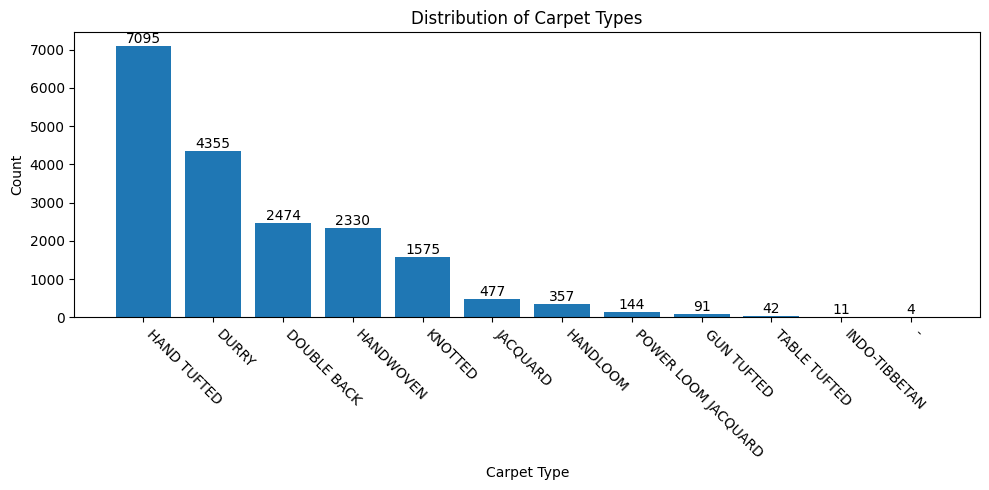

In [72]:



# Calculate the count of occurrences for each unique value in `ITEM_NAME`
item_name_counts = raw_data_order_df['ITEM_NAME'].value_counts()

# Convert the Series to a DataFrame for easier plotting
item_name_counts_df = item_name_counts.reset_index()

# Plotting with Matplotlib
plt.figure(figsize=(10, 5))  # Adjust size as needed

plt.bar(item_name_counts_df['index'], item_name_counts_df['ITEM_NAME'])

plt.xlabel('Carpet Type')
plt.ylabel('Count')
plt.title('Distribution of Carpet Types')
plt.xticks(rotation=-45, ha='left')  # Rotate labels for better readability
plt.tight_layout()

# Adding tooltips (optional, but enhances interactivity)
for i, v in enumerate(item_name_counts_df['ITEM_NAME']):
    plt.text(i, v, str(v), ha='center', va='bottom')  # Display count above each bar

# Save the chart (you can choose various formats like PNG, SVG, etc.)
plt.savefig('carpet_type_distribution_bar_chart.png') 

plt.show()  # Display the chart


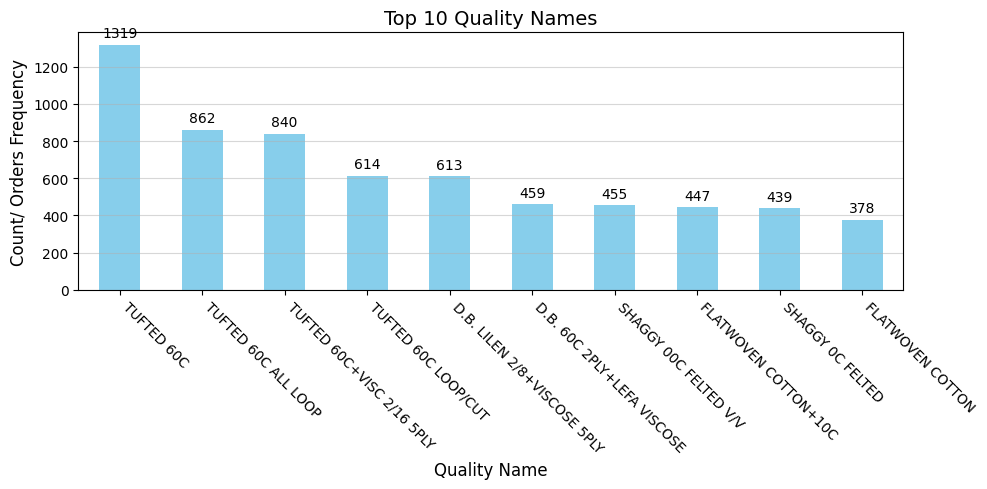

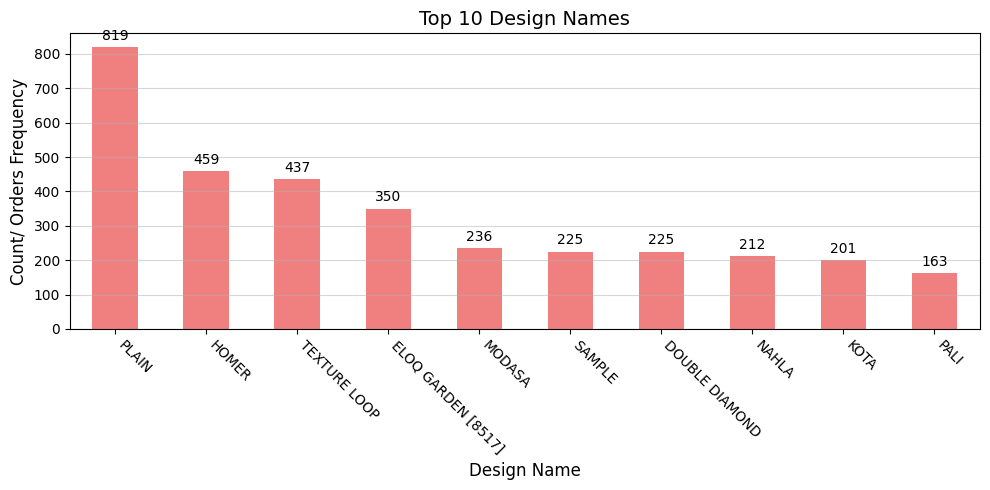

In [78]:
import matplotlib.pyplot as plt

# Assuming raw_data_order_df is your DataFrame
quality_name_counts = raw_data_order_df['QualityName'].value_counts().head(10)
design_name_counts = raw_data_order_df['DesignName'].value_counts().head(10)

# Plotting the top 10 Quality Names with data labels
plt.figure(figsize=(10, 5))  # Slightly wider figure for better label display
ax = quality_name_counts.plot(kind='bar', color='skyblue')
plt.title('Top 10 Quality Names', fontsize=14)
plt.xlabel('Quality Name', fontsize=12)
plt.ylabel('Count/ Orders Frequency', fontsize=12)
plt.xticks(rotation=-45, ha='left', fontsize=10) 
plt.yticks(fontsize=10)
plt.grid(axis='y', alpha=0.5)  # Add a subtle horizontal grid

# Add data labels on top of the bars
for container in ax.containers:
    ax.bar_label(container, padding=3, fmt='%d')

plt.tight_layout()
plt.show()


# Plotting the top 10 Design Names (similar to above)
plt.figure(figsize=(10, 5))
ax = design_name_counts.plot(kind='bar', color='lightcoral')
plt.title('Top 10 Design Names', fontsize=14)
plt.xlabel('Design Name', fontsize=12)
plt.ylabel('Count/ Orders Frequency', fontsize=12)
plt.xticks(rotation=-45, ha='left', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', alpha=0.5)

# Add data labels on top of the bars
for container in ax.containers:
    ax.bar_label(container, padding=3, fmt='%d')

plt.tight_layout()
plt.show()


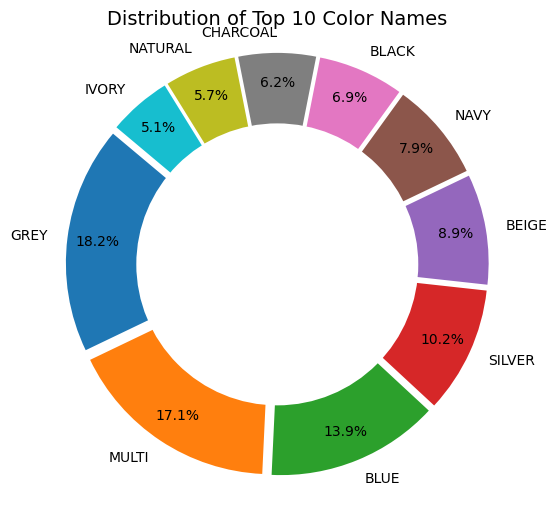

In [82]:
import matplotlib.pyplot as plt

# Get top 10 colors and their counts
top_10_colors = raw_data_order_df['ColorName'].value_counts().head(10)

# Pie chart for top 10 ColorName distribution
plt.figure(figsize=(6, 6))  # Slightly larger for better label spacing

# Explode the slices slightly for better readability
explode = [0.05] * len(top_10_colors) 

# Adjust label distance and percentage formatting
plt.pie(top_10_colors, 
        labels=top_10_colors.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        explode=explode,
        pctdistance=0.85,  # Move percentages closer to center
        labeldistance=1.1)  # Move labels slightly further out

plt.title('Distribution of Top 10 Color Names', fontsize=14)
plt.axis('equal')

# Add a white circle in the middle to enhance label readability
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.show()

# --- Optional: Bar chart for alternative visualization ---
# plt.figure(figsize=(12, 6))
# top_10_colors.plot(kind='bar', rot=45)  
# plt.title('Distribution of Top 10 Color Names', fontsize=14)
# plt.xlabel('Color Name')
# plt.ylabel('Number of Orders')
# plt.show()


In [85]:
raw_data_order_df['ShapeName'].value_counts()

REC        18518
ROUND        362
SQUARE        72
OCTAGON        2
OVAL           1
Name: ShapeName, dtype: int64

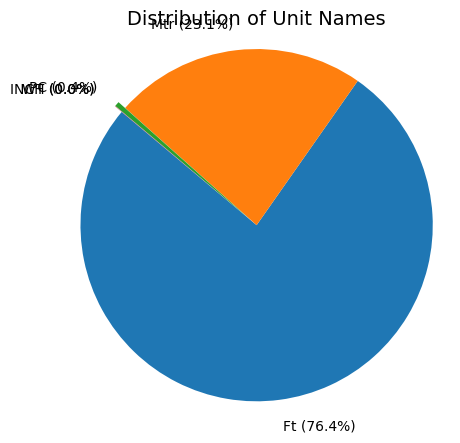

In [91]:

# Assuming you already have the 'unit_name_counts' data
unit_name_counts = raw_data_order_df['UnitName'].value_counts()

# Plotting the Pie Chart with Matplotlib
plt.figure(figsize=(5, 5))  # Increase figure size for more space

# Calculate percentages manually and round to 1 decimal place
percentages = 100 * unit_name_counts / unit_name_counts.sum()
labels = [f"{label} ({pct:.1f}%)" for label, pct in zip(unit_name_counts.index, percentages)]

# Explode the slices slightly for better separation
explode = [0.05 if pct < 10 else 0 for pct in percentages]  # Explode small slices more

# Adjust parameters for better label placement
plt.pie(unit_name_counts, 
        labels=labels,          # Use the combined labels
        startangle=140, 
        explode=explode,        
        pctdistance=0.85,       # Move percentages closer to center
        labeldistance=1.15)     # Move labels further out

plt.title('Distribution of Unit Names', fontsize=14)
plt.axis('equal')

plt.show()



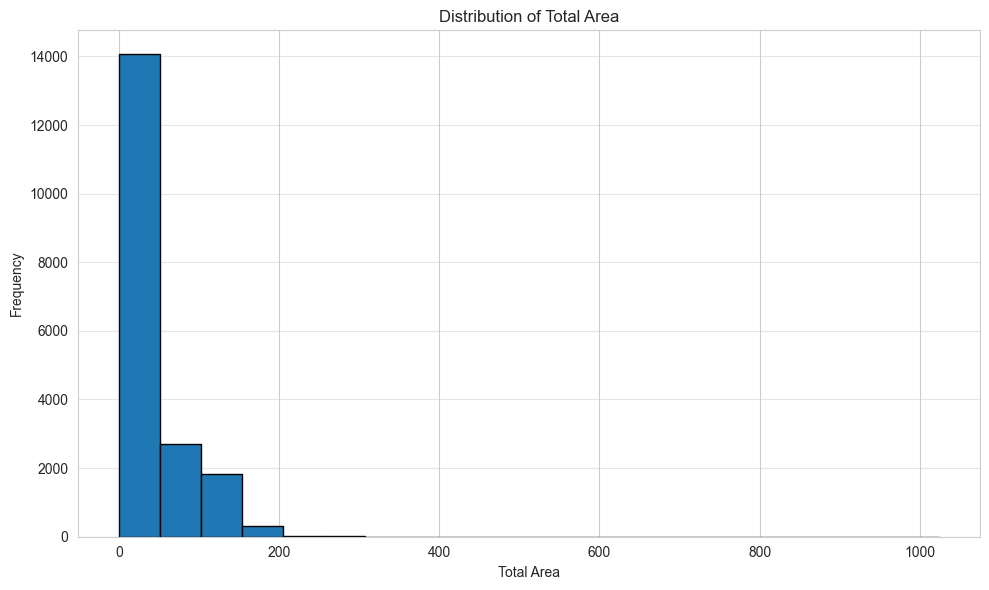

In [93]:
import matplotlib.pyplot as plt

# Assuming you have your DataFrame `df` with a 'TotalArea' column
plt.figure(figsize=(10, 6))
plt.hist(raw_data_order_df['TotalArea'], bins=20, edgecolor='k')  # Adjust the number of bins as needed
plt.title('Distribution of Total Area')
plt.xlabel('Total Area')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.5)  # Add a subtle grid
plt.tight_layout()
plt.savefig('total_area_distribution_histogram_matplotlib.png')  # Save as PNG or PDF
plt.show()


Mean Total Area: 36.151209575309935
Median Total Area: 15.0


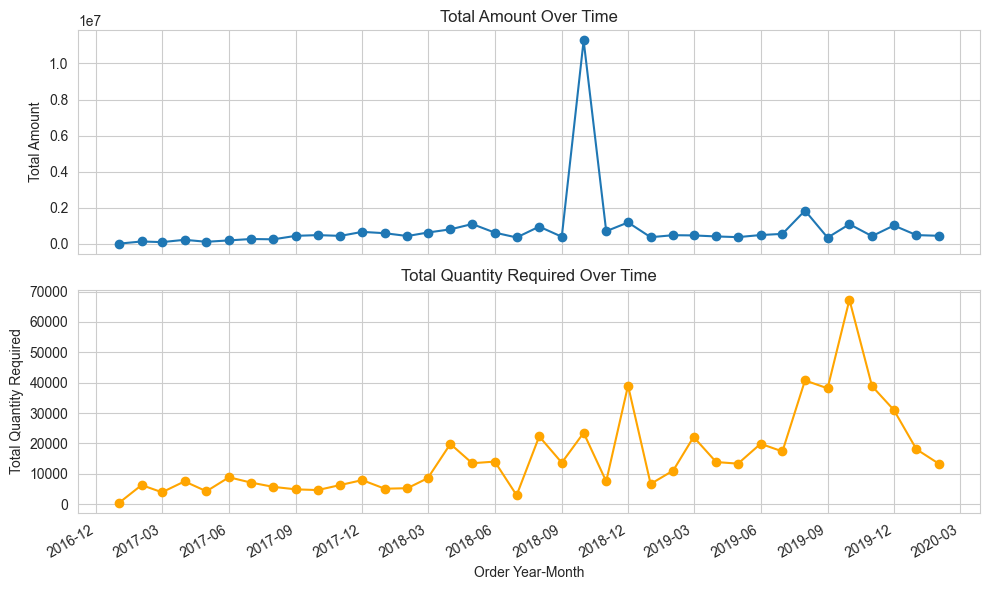

In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Calculate and print the mean and median of `TotalArea`
print(f"Mean Total Area: {raw_data_order_df['TotalArea'].mean()}")
print(f"Median Total Area: {raw_data_order_df['TotalArea'].median()}")

# Convert `Custorderdate` to datetime format
raw_data_order_df['Custorderdate'] = pd.to_datetime(raw_data_order_df['Custorderdate'])

# Extract year and month from `Custorderdate` and create a new column `OrderYearMonth`
raw_data_order_df['OrderYearMonth'] = raw_data_order_df['Custorderdate'].dt.to_period('M')

# Group by `OrderYearMonth` and calculate the total `Amount` for each month
amount_over_time = raw_data_order_df.groupby('OrderYearMonth')['Amount'].sum().reset_index()


# Convert `OrderYearMonth` to string format
amount_over_time['OrderYearMonth'] = amount_over_time['OrderYearMonth'].astype(str)

# Group by `OrderYearMonth` and calculate the sum of `QtyRequired` for each month
quantity_over_time = raw_data_order_df.groupby(raw_data_order_df['OrderYearMonth'].astype(str))['QtyRequired'].sum().reset_index()


# Convert 'OrderYearMonth' back to datetime for plotting
amount_over_time['OrderYearMonth'] = pd.to_datetime(amount_over_time['OrderYearMonth'])
quantity_over_time['OrderYearMonth'] = pd.to_datetime(quantity_over_time['OrderYearMonth'])


# Plotting with Matplotlib
fig, axes = plt.subplots(2, 1, figsize=(10, 6))  # 2 rows, 1 column for subplots

# Plot Total Amount Over Time
axes[0].plot(amount_over_time['OrderYearMonth'], amount_over_time['Amount'], marker='o')
axes[0].set_title('Total Amount Over Time')
axes[0].set_xlabel('Order Year-Month')
axes[0].set_ylabel('Total Amount')
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # Show every 3 months
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate() # Auto-format the x-axis dates

# Plot Total Quantity Required Over Time
axes[1].plot(quantity_over_time['OrderYearMonth'], quantity_over_time['QtyRequired'], marker='o', color='orange')
axes[1].set_title('Total Quantity Required Over Time')
axes[1].set_xlabel('Order Year-Month')
axes[1].set_ylabel('Total Quantity Required')
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # Show every 3 months
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate() # Auto-format the x-axis dates

# Adjust layout for better readability
plt.tight_layout()

# Show the plots
plt.show()

# Optional: Save the figure
# fig.savefig('order_trends.png')  


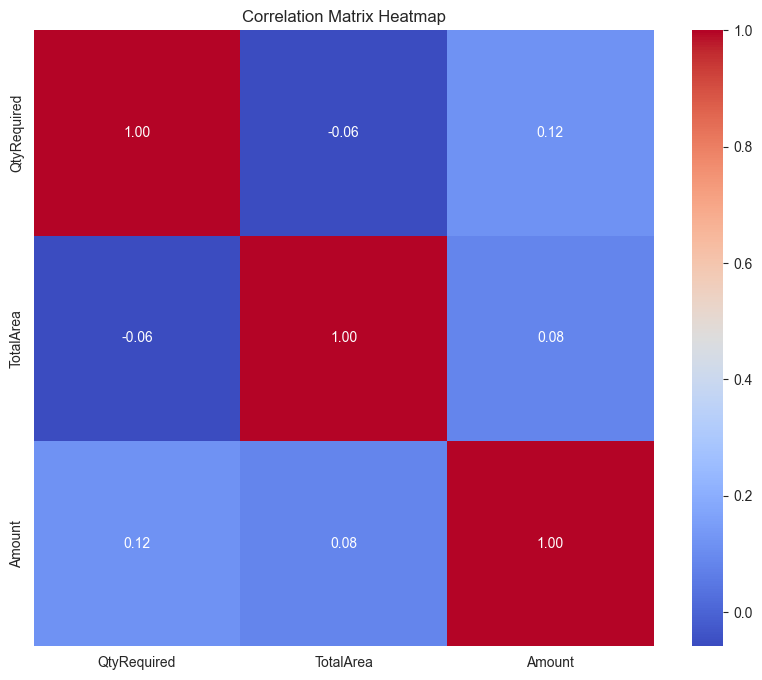

Correlation Matrix:
|             | QtyRequired   | TotalArea   | Amount    |
|:------------|:--------------|:------------|:----------|
| QtyRequired | 1             | -0.0589895  | 0.116813  |
| TotalArea   | -0.0589895    | 1           | 0.0828184 |
| Amount      | 0.116813      | 0.0828184   | 1         |


In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Filter the dataframe to include only the columns `QtyRequired`, `TotalArea`, and `Amount`
filtered_df = raw_data_order_df[['QtyRequired', 'TotalArea', 'Amount']]

# Calculate correlation matrix (same as before)
correlation_matrix = filtered_df.corr()

# Create heatmap using Seaborn
plt.figure(figsize=(10, 8))  # Optional: Adjust figure size
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.savefig('correlation_matrix_heatmap.png')  # Save as PNG
plt.show()  # Display the plot

# Print correlation matrix in markdown format (same as before)
print("Correlation Matrix:")
print(correlation_matrix.to_markdown(numalign="left", stralign="left"))
